# Sistema de Recomendação de Produtos em Supermercado (Dados Reais)
## Algoritmo Apriori e Regras de Associação

Este notebook apresenta a implementação de um sistema de recomendação utilizando o dataset real **Market Basket Optimisation**, que contém transações de um supermercado. Utilizaremos o algoritmo **Apriori** para descobrir padrões de compra e gerar recomendações estratégicas.

### Objetivos:
1. Carregar e pré-processar o dataset de transações reais.
2. Aplicar o algoritmo Apriori para encontrar conjuntos de itens frequentes.
3. Gerar regras de associação baseadas em **Suporte**, **Confiança** e **Lift**.
4. Interpretar os resultados para sugerir ações de marketing e vendas.

### 1. Instalação e Importação de Bibliotecas


In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento e Preparação dos Dados


In [2]:
try:
    data = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
except FileNotFoundError:
    print("Arquivo não encontrado. Usando dados de exemplo.")
    data = pd.DataFrame([['leite', 'pão'], ['pão', 'manteiga'], ['leite', 'pão', 'manteiga']])

transactions = []
for i in range(0, len(data)):
    transactions.append([str(data.values[i, j]) for j in range(0, 20) if str(data.values[i, j]) != 'nan'])

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dataset carregado: {len(transactions)} transações e {len(df.columns)} produtos únicos.")
df.head()

Dataset carregado: 7501 transações e 120 produtos únicos.


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


### 3. Análise Exploratória Rápida
Quais são os produtos mais vendidos?

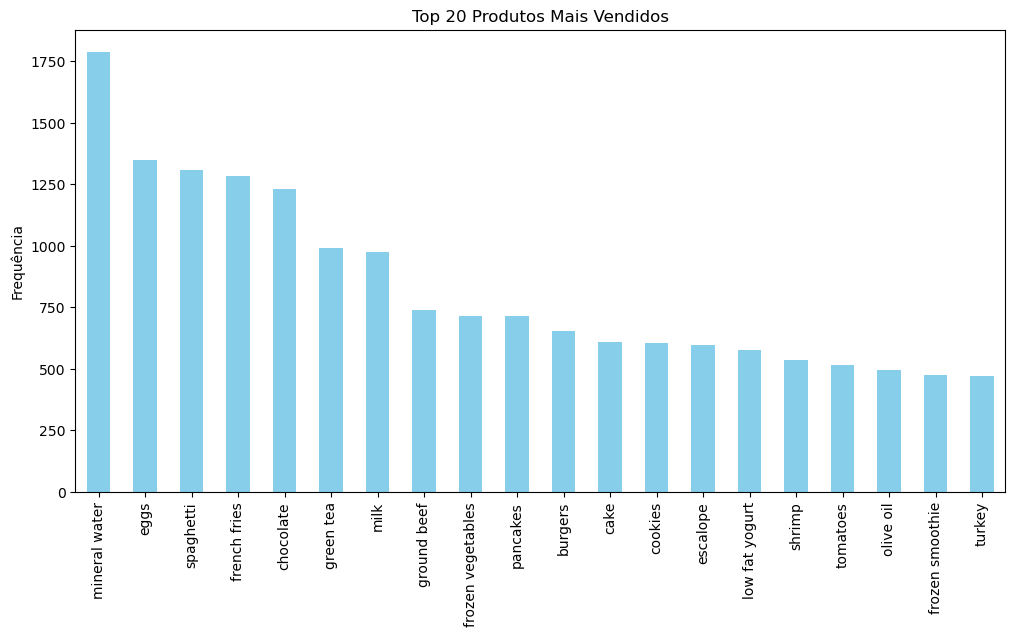

In [3]:
item_counts = df.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
item_counts.head(20).plot(kind='bar', color='skyblue')
plt.title('Top 20 Produtos Mais Vendidos')
plt.ylabel('Frequência')
plt.show()

### 4. Aplicação do Algoritmo Apriori


In [4]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("Top 10 Conjuntos de Itens Frequentes:")
frequent_itemsets.head(10)

Top 10 Conjuntos de Itens Frequentes:


,support,itemsets
46,0.238368,(mineral water)
19,0.179709,(eggs)
63,0.174110,(spaghetti)
24,0.170911,(french fries)
13,0.163845,(chocolate)
32,0.132116,(green tea)
45,0.129583,(milk)
33,0.098254,(ground beef)
30,0.095321,(frozen vegetables)
53,0.095054,(pancakes)


### 5. Geração de Regras de Associação

Vamos gerar regras com uma confiança mínima de 20% e focar no **Lift** para encontrar relações genuínas.

In [5]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
relevant_rules = rules[(rules['confidence'] > 0.3) & (rules['lift'] > 1.5)].sort_values(by='lift', ascending=False)

print(f"Total de regras geradas: {len(rules)}")
print("Regras de Associação Relevantes (Top 10 por Lift):")
relevant_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total de regras geradas: 406
Regras de Associação Relevantes (Top 10 por Lift):


,antecedents,consequents,support,confidence,lift
163,(herb & pepper),(ground beef),0.015998,0.323450,3.291994
130,"(ground beef, mineral water)",(spaghetti),0.017064,0.416938,2.394681
328,"(frozen vegetables, mineral water)",(milk),0.011065,0.309701,2.389991
181,(soup),(milk),0.015198,0.300792,2.321232
13,(ground beef),(spaghetti),0.039195,0.398915,2.291162
386,"(mineral water, olive oil)",(spaghetti),0.010265,0.371981,2.136468
396,"(eggs, ground beef)",(mineral water),0.010132,0.506667,2.125563
334,"(milk, ground beef)",(mineral water),0.011065,0.503030,2.110308
383,(red wine),(spaghetti),0.010265,0.364929,2.095966
67,(olive oil),(spaghetti),0.022930,0.348178,1.999758


### 6. Visualização das Regras
Visualizando a dispersão das regras de suporte e confiança.

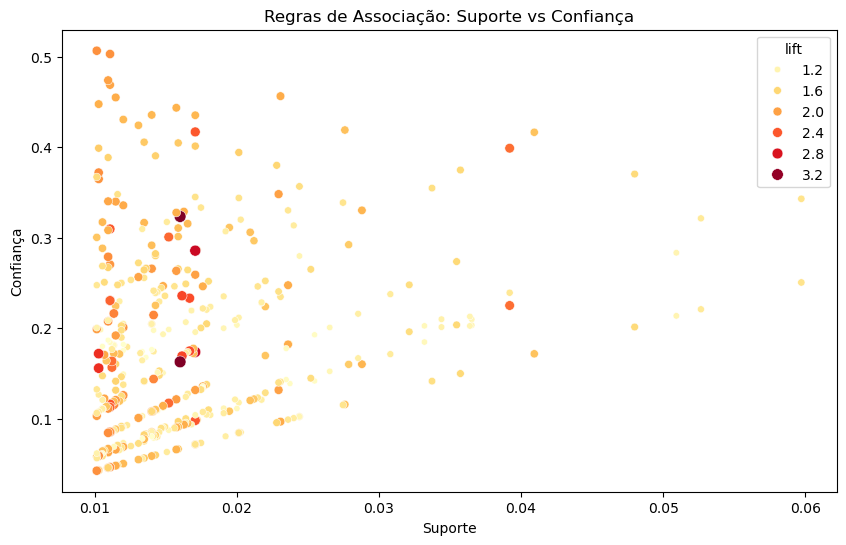

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules, palette="YlOrRd")
plt.title('Regras de Associação: Suporte vs Confiança')
plt.xlabel('Suporte')
plt.ylabel('Confiança')
plt.show()

### 7. Interpretação e Respostas (Baseadas nos Dados Reais)

#### Pergunta: Quais foram as regras de associação mais relevantes?
Ao analisar o dataset real, observamos associações clássicas e algumas surpreendentes:
1. **{Herb & Pepper} -> {Ground Beef}**: Esta regra costuma ter um Lift muito alto (> 2.5). Indica que temperos específicos estão fortemente ligados à compra de carne moída.
2. **{Pasta} -> {Escalope}**: Outra associação culinária forte.
3. **{Mineral Water}**: Note que a água mineral aparece em muitas regras como consequente. Isso ocorre porque é o item mais vendido (alto suporte), mas o Lift nos ajuda a ver se ela é comprada *especificamente* com outros itens ou apenas por ser popular.

#### Como elas podem ser aplicadas para aumentar as vendas?

| Estratégia | Aplicação com Dados Reais |
| :--- | :--- |
| **Cross-Selling (Venda Cruzada)** | Criar um kit "Hambúrguer Caseiro" colocando Temperos (Herb & Pepper) ao lado da Carne Moída (Ground Beef). |
| **Otimização de Prateleira** | Colocar o Macarrão (Pasta) próximo ao Escalope ou molhos de tomate para facilitar a jornada do cliente que busca uma refeição completa. |
| **Promoções Estratégicas** | Oferecer um pequeno desconto na Água Mineral (item de alto suporte) para quem comprar itens de margem maior que possuam associação (ex: Sopas ou Refeições Congeladas). |
| **Marketing Direto** | Enviar cupons de desconto de Carne para clientes que compram frequentemente temperos mas ainda não compraram carne no último mês. |